# Application laboratory: LDPC decoding as graphical-model inference

A binary linear code is defined by a parity-check matrix $H$. A word $x\in\{0,1\}^N$ is a valid codeword when

$$
Hx=0 \pmod 2.
$$

After transmission through a noisy memoryless channel, decoding becomes inference in a factor graph: parity checks are hard factors, while channel likelihoods are unary soft factors. We compare exact decoding with sum-product belief propagation on a small Hamming-code example.

In [1]:
CHAPTER_DIR="ch11"

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

CWD = Path.cwd()
if CWD.name.startswith("ch"):
    NOTEBOOK_DIR = CWD
elif (CWD / "notebooks" / CHAPTER_DIR).exists():
    NOTEBOOK_DIR = CWD / "notebooks" / CHAPTER_DIR
else:
    NOTEBOOK_DIR = CWD
FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RNG = np.random.default_rng(577)

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 17,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
    "figure.titlesize": 18,
})

def save_figure(fig, stem):
    fig.savefig(FIG_DIR / f"{stem}.pdf", bbox_inches="tight")
    fig.savefig(FIG_DIR / f"{stem}.png", dpi=240, bbox_inches="tight")
    print("Saved", stem)

def draw_dark_nodes(G, pos, labels=None, ax=None, node_size=1200, arrows=False, **kwargs):
    if ax is None: ax=plt.gca()
    nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color="#303030", edgecolors="black", ax=ax)
    nx.draw_networkx_labels(G, pos, labels=labels, font_color="white", font_size=13, ax=ax)
    nx.draw_networkx_edges(G, pos, arrows=arrows, arrowsize=20, width=1.8, ax=ax, **kwargs)
    return ax

def annotate_heatmap(ax, image, values, fmt=".2f"):
    arr=np.asarray(values)
    lo,hi=np.nanmin(arr),np.nanmax(arr)
    mid=(lo+hi)/2
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            color="white" if arr[i,j] < mid else "black"
            ax.text(j,i,format(arr[i,j],fmt),ha="center",va="center",color=color,fontsize=11)

In [2]:
from itertools import product

H=np.array([[1,0,1,0,1,0,1],
            [0,1,1,0,0,1,1],
            [0,0,0,1,1,1,1]],dtype=int)
M,N=H.shape
all_x=np.array(list(product([0,1], repeat=N)),dtype=int)
valid=all_x[(all_x@H.T % 2 ==0).all(axis=1)]
print('number of codewords:',len(valid))
true_x=valid[9].copy()
noise_sigma=.85
signal=1-2*true_x
y=signal+RNG.normal(scale=noise_sigma,size=N)
logw=-((y[None,:]-(1-2*valid))**2).sum(axis=1)/(2*noise_sigma**2)
logw-=logw.max(); p=np.exp(logw); p/=p.sum()
map_x=valid[np.argmax(p)]
exact_p1=(p[:,None]*valid).sum(axis=0)
print('transmitted:',true_x)
print('MAP        :',map_x)
print('exact P(bit=1):',np.round(exact_p1,3))

number of codewords: 16
transmitted: [1 0 0 1 1 0 0]
MAP        : [1 0 0 1 1 0 0]
exact P(bit=1): [1.    0.003 0.001 0.998 1.    0.002 0.   ]


/tmp/ipykernel_7533/1440664098.py:38: UserWarning: 

The arrowsize keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(G, pos, arrows=arrows, arrowsize=20, width=1.8, ax=ax, **kwargs)


Saved ch11_02_tanner_graph


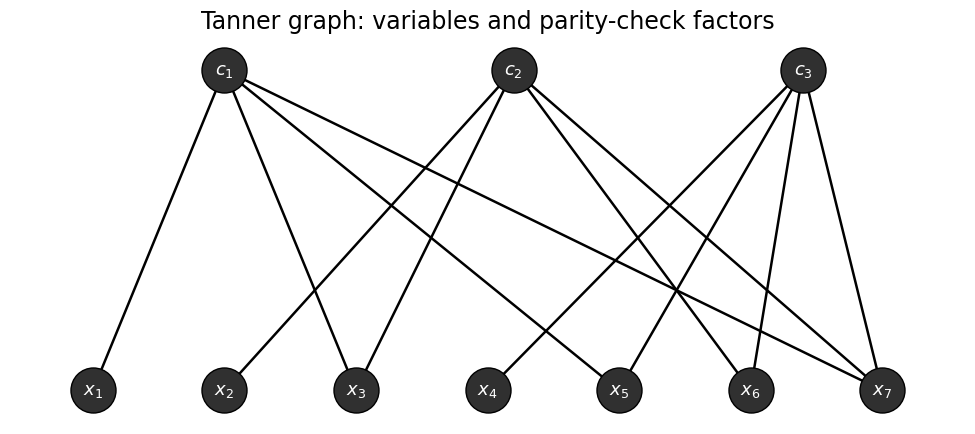

In [3]:
# Tanner graph
G=nx.Graph(); vars=[f'x{i+1}' for i in range(N)]; checks=[f'c{a+1}' for a in range(M)]
G.add_nodes_from(vars,bipartite=0); G.add_nodes_from(checks,bipartite=1)
for a in range(M):
    for i in np.where(H[a])[0]: G.add_edge(checks[a],vars[i])
pos={v:(i,0) for i,v in enumerate(vars)}; pos.update({c:(1+2.2*a,1.6) for a,c in enumerate(checks)})
fig,ax=plt.subplots(figsize=(10,4.6)); draw_dark_nodes(G,pos,labels={n:('$'+n[0]+'_{'+n[1:]+'}$') for n in G},ax=ax,node_size=1050)
ax.set_title("Tanner graph: variables and parity-check factors"); ax.axis('off'); fig.tight_layout(); save_figure(fig,'ch11_02_tanner_graph'); plt.show()

In [4]:
# Sum-product in LLR form.
neigh_c={a:list(np.where(H[a])[0]) for a in range(M)}
neigh_v={i:list(np.where(H[:,i])[0]) for i in range(N)}
channel_llr=2*y/noise_sigma**2  # log p(y|x=0)/p(y|x=1)
v2c={(i,a):channel_llr[i] for i in range(N) for a in neigh_v[i]}
c2v={(a,i):0.0 for a in range(M) for i in neigh_c[a]}
for it in range(30):
    new_c={}
    for a in range(M):
        for i in neigh_c[a]:
            vals=[np.tanh(v2c[(j,a)]/2) for j in neigh_c[a] if j!=i]
            prodv=np.prod(vals) if vals else 1.0
            prodv=np.clip(prodv,-1+1e-12,1-1e-12)
            new_c[(a,i)]=2*np.arctanh(prodv)
    c2v=new_c
    new_v={}
    for i in range(N):
        for a in neigh_v[i]: new_v[(i,a)]=channel_llr[i]+sum(c2v[(b,i)] for b in neigh_v[i] if b!=a)
    v2c=new_v
bp_llr=np.array([channel_llr[i]+sum(c2v[(a,i)] for a in neigh_v[i]) for i in range(N)])
bp_p1=1/(1+np.exp(bp_llr))
print('BP P(bit=1):',np.round(bp_p1,3))

BP P(bit=1): [1.    0.002 0.    0.998 1.    0.002 0.   ]


<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_7533/818392819.py:5: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xticks(i,[rf'$x_{k+1}$' for k in i]); ax.set_ylim(0,1); ax.set_ylabel('$P(x_i=1\mid y)$')


Saved ch11_02_exact_vs_bp_marginals


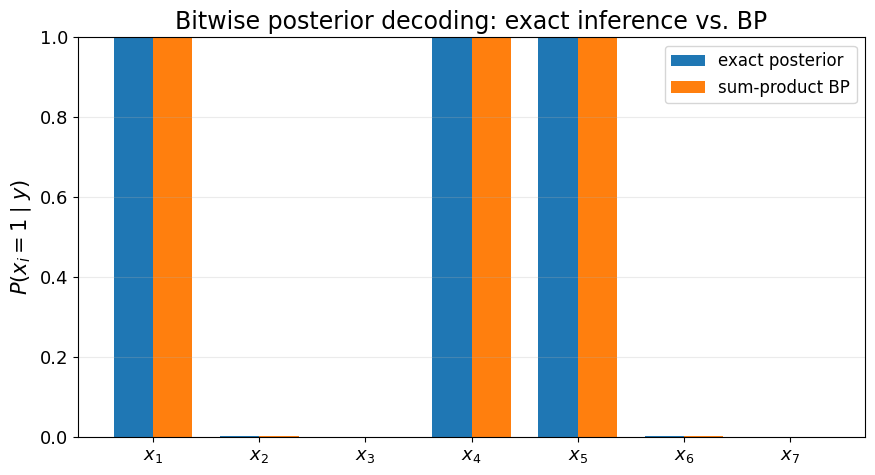

In [5]:
fig,ax=plt.subplots(figsize=(9,5))
i=np.arange(N); w=.37
ax.bar(i-w/2,exact_p1,w,label='exact posterior')
ax.bar(i+w/2,bp_p1,w,label='sum-product BP')
ax.set_xticks(i,[rf'$x_{k+1}$' for k in i]); ax.set_ylim(0,1); ax.set_ylabel('$P(x_i=1\mid y)$')
ax.set_title("Bitwise posterior decoding: exact inference vs. BP")
ax.legend(); ax.grid(axis='y',alpha=.25); fig.tight_layout(); save_figure(fig,'ch11_02_exact_vs_bp_marginals'); plt.show()

## Stress test: loopy BP can fail, and the failure depends on the factorization

Exact decoding depends only on the code and the channel likelihood. Loopy BP also depends on the **chosen Tanner-graph representation**. Adding a redundant parity check does not change the set of valid codewords, but it changes the loops seen by BP.

To expose this distinction, we keep one fixed standardized noise direction and vary the channel noise scale. For every value of $\sigma$ we compute exact bit marginals, BP marginals on the original Tanner graph, and BP marginals after adding one redundant parity check. In the easy low-noise regime all three agree. At intermediate noise the same exact posterior can lead to visibly different BP errors.

Saved ch11_02_bp_stress_test


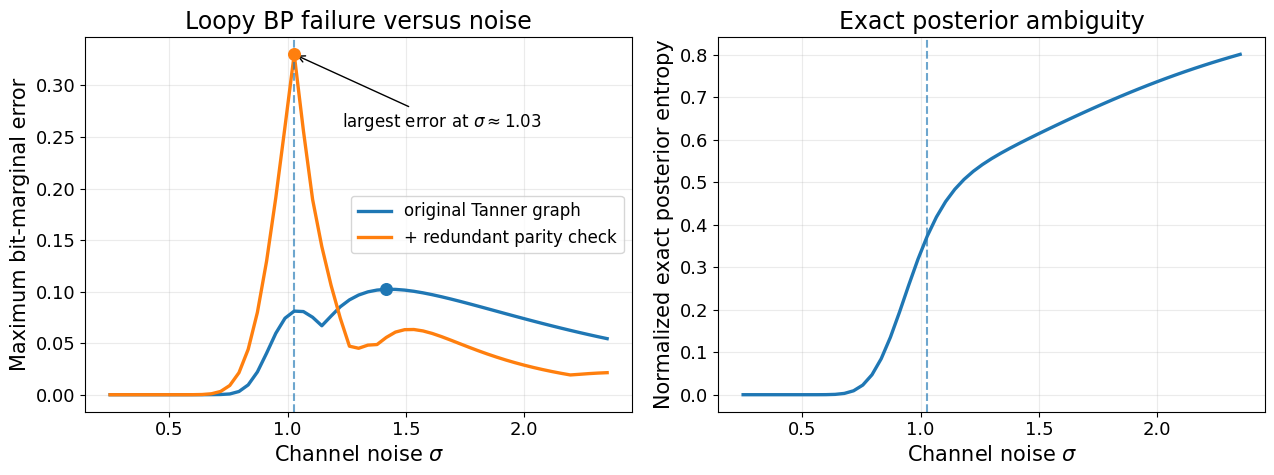

Original Tanner graph: max error=0.102 at sigma=1.417
Redundant-check graph: max error=0.330 at sigma=1.028


In [6]:
def exact_bit_marginals(H_local, y_local, sigma_local):
    states_local = np.array(list(product([0, 1], repeat=H_local.shape[1])), dtype=int)
    valid_local = states_local[(states_local @ H_local.T % 2 == 0).all(axis=1)]
    logw_local = -((y_local[None, :] - (1 - 2 * valid_local))**2).sum(axis=1) / (2 * sigma_local**2)
    logw_local -= logw_local.max()
    p_local = np.exp(logw_local)
    p_local /= p_local.sum()
    return (p_local[:, None] * valid_local).sum(axis=0)

def bp_bit_marginals(H_local, y_local, sigma_local, iterations=60, damping=0.0):
    M_local, N_local = H_local.shape
    neigh_c_local = {a: list(np.where(H_local[a])[0]) for a in range(M_local)}
    neigh_v_local = {i: list(np.where(H_local[:, i])[0]) for i in range(N_local)}
    llr_local = 2 * y_local / sigma_local**2
    v2c_local = {(i, a): llr_local[i] for i in range(N_local) for a in neigh_v_local[i]}
    c2v_local = {(a, i): 0.0 for a in range(M_local) for i in neigh_c_local[a]}
    for _ in range(iterations):
        new_c = {}
        for a in range(M_local):
            for i in neigh_c_local[a]:
                values = [np.tanh(v2c_local[(j, a)] / 2) for j in neigh_c_local[a] if j != i]
                product_value = np.prod(values) if values else 1.0
                product_value = np.clip(product_value, -1 + 1e-12, 1 - 1e-12)
                raw = 2 * np.arctanh(product_value)
                new_c[(a, i)] = damping * c2v_local[(a, i)] + (1 - damping) * raw
        c2v_local = new_c

        new_v = {}
        for i in range(N_local):
            for a in neigh_v_local[i]:
                raw = llr_local[i] + sum(c2v_local[(b, i)] for b in neigh_v_local[i] if b != a)
                new_v[(i, a)] = damping * v2c_local[(i, a)] + (1 - damping) * raw
        v2c_local = new_v

    bp_llr_local = np.array([
        llr_local[i] + sum(c2v_local[(a, i)] for a in neigh_v_local[i]) for i in range(N_local)
    ])
    return 1 / (1 + np.exp(np.clip(bp_llr_local, -700, 700)))

redundant_check = (H[0] ^ H[1])[None, :]
H_redundant = np.vstack([H, redundant_check])

states_all = np.array(list(product([0, 1], repeat=N)), dtype=int)
valid_redundant = states_all[(states_all @ H_redundant.T % 2 == 0).all(axis=1)]
assert {tuple(x) for x in valid_redundant} == {tuple(x) for x in valid}

rng_stress = np.random.default_rng(901)
noise_direction = rng_stress.normal(size=N)
sigma_grid = np.linspace(0.25, 2.35, 55)
err_original = []
err_redundant = []
posterior_entropy = []

for sigma_test in sigma_grid:
    y_test = signal + sigma_test * noise_direction
    exact_test = exact_bit_marginals(H, y_test, sigma_test)
    bp_original = bp_bit_marginals(H, y_test, sigma_test)
    bp_redundant = bp_bit_marginals(H_redundant, y_test, sigma_test)
    err_original.append(np.max(np.abs(bp_original - exact_test)))
    err_redundant.append(np.max(np.abs(bp_redundant - exact_test)))

    logw_test = -((y_test[None, :] - (1 - 2 * valid))**2).sum(axis=1) / (2 * sigma_test**2)
    logw_test -= logw_test.max()
    p_test = np.exp(logw_test)
    p_test /= p_test.sum()
    posterior_entropy.append(-np.sum(p_test * np.log(np.clip(p_test, 1e-300, None))))

err_original = np.asarray(err_original)
err_redundant = np.asarray(err_redundant)
posterior_entropy = np.asarray(posterior_entropy)

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.0))
idx_original = int(np.argmax(err_original))
idx_redundant = int(np.argmax(err_redundant))
sigma_original = float(sigma_grid[idx_original])
sigma_redundant = float(sigma_grid[idx_redundant])

axes[0].plot(sigma_grid, err_original, linewidth=2.4, label="original Tanner graph")
axes[0].plot(sigma_grid, err_redundant, linewidth=2.4, label="+ redundant parity check")
axes[0].scatter([sigma_original], [err_original[idx_original]], s=70, zorder=5)
axes[0].scatter([sigma_redundant], [err_redundant[idx_redundant]], s=70, zorder=5)
axes[0].axvline(sigma_redundant, linestyle="--", linewidth=1.5, alpha=0.65)
axes[0].annotate(
    rf"largest error at $\sigma\approx{sigma_redundant:.2f}$",
    xy=(sigma_redundant, err_redundant[idx_redundant]),
    xytext=(sigma_redundant + 0.20, err_redundant[idx_redundant] - 0.07),
    arrowprops=dict(arrowstyle="->"), fontsize=12,
)
axes[0].set_xlabel(r"Channel noise $\sigma$")
axes[0].set_ylabel("Maximum bit-marginal error")
axes[0].set_title("Loopy BP failure versus noise")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(sigma_grid, posterior_entropy / np.log(len(valid)), linewidth=2.4)
axes[1].axvline(sigma_redundant, linestyle="--", linewidth=1.5, alpha=0.65)
axes[1].set_xlabel(r"Channel noise $\sigma$")
axes[1].set_ylabel("Normalized exact posterior entropy")
axes[1].set_title("Exact posterior ambiguity")
axes[1].grid(alpha=0.25)
fig.tight_layout()
save_figure(fig, "ch11_02_bp_stress_test")
plt.show()

print(f"Original Tanner graph: max error={err_original[idx_original]:.3f} at sigma={sigma_original:.3f}")
print(f"Redundant-check graph: max error={err_redundant[idx_redundant]:.3f} at sigma={sigma_redundant:.3f}")

## Exercises

1. Sweep the channel noise level and compare word-MAP error, bitwise-MAP error, and BP marginal error. Identify the crossover at which BP first becomes visibly inaccurate.
2. Add a redundant parity check. The code remains unchanged, but the Tanner graph acquires additional loops. Explain why the exact posterior is unchanged while BP may change.
3. At the value of $\sigma$ where the redundant-check representation has its largest marginal error, compare exact marginals, BP marginals, bitwise hard decisions, and word MAP. Then vary damping and iteration count. Which errors are solver effects and which persist because the loopy fixed point itself is inaccurate?
4. Replace sum-product by min-sum and compare the resulting hard decision with exact word MAP.
5. Formulate LP decoding for this code and identify a noise realization that gives a fractional pseudocodeword.